In [2]:
import numpy as np
from dataclasses import dataclass
from importlib import reload
import weights as Weights

In [14]:
int(*{1,2})

TypeError: int() can't convert non-string with explicit base

In [4]:
reload(Weights)
from weights import WeightMatrix

network = {
     1: [3, 2],
     2: [3, 4],
     3: [2, 1],
     4: [2, 3]
 }

n = 4           # matrix size
density = 0.1    # fraction of nonzero entries
np.random.seed(100)
mask = np.random.rand(n, n) < density
values = np.random.randn(n, n) * mask

k = np.ceil(0.05*n).astype(np.int64)
U,V = np.random.normal(size=(2,n,k))

weights = WeightMatrix(U,V, network)
I,J = np.where(mask)

# make weights approximate the values matrix
for _ in range(10):
    # Update weights at I,J to better reflect values[I,J]
    weights.at[I,J] <<= values[I,J] - weights[I,J]

print(f"MSE: {((values[I, J] - weights[I, J]) ** 2).mean()}")

MSE: 3.395285438881416e-06


In [10]:
for j in weights.children[1]:
    print(j)

3
2


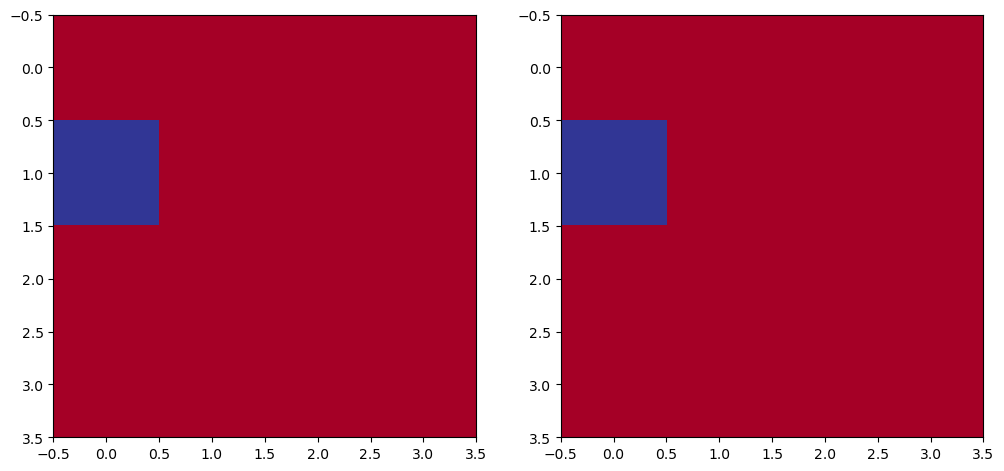

In [5]:
from matplotlib import pyplot as plt
w = weights[np.mgrid[0:n, 0:n]]
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
maxv = values.max()
minv  = values.min()

ax1.imshow(values, cmap='RdYlBu', vmin=minv, vmax=maxv)
ax2.imshow((w*mask), cmap='RdYlBu', vmax=maxv, vmin=minv)

In [977]:
weights.save("testing.npz")

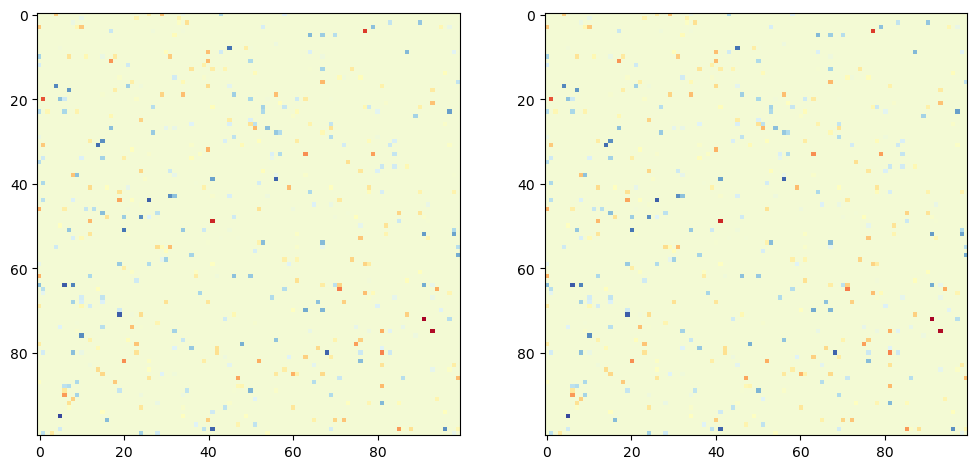

In [980]:
weights_2 = WeightMatrix()
weights_2.load_from_disk('testing.npz')

from matplotlib import pyplot as plt
w2 = weights_2[np.mgrid[0:n, 0:n]]
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
maxv = values.max()
minv  = values.min()

ax1.imshow((w*mask), cmap='RdYlBu', vmin=minv, vmax=maxv)
ax2.imshow((w2*mask), cmap='RdYlBu', vmax=maxv, vmin=minv)

In [972]:
import numpy as np, os, glob, zipfile

u = np.arange(5)
v = np.arange(5,10)

np.savez_compressed("test.npz", u=u, v=v)

print("Files on disk:", glob.glob("test*"))
with zipfile.ZipFile("test.npz") as z:
    print("Inside zip:", z.namelist())


Files on disk: ['test.npz']
Inside zip: ['u.npy', 'v.npy']


TypeError: Each element must be int or list of ints

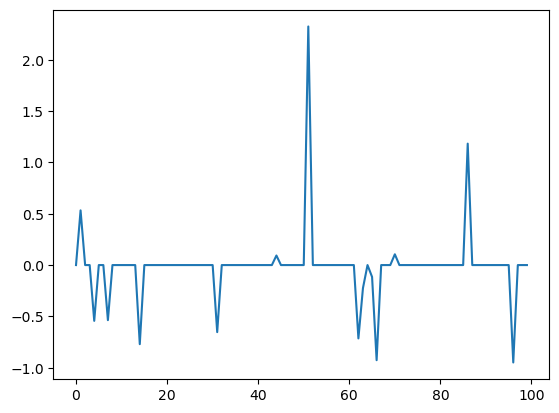

In [685]:
plt.plot(values[10])
plt.plot(weights)

array([ 0.87760178,  1.27751203,  0.36613982,  0.19009868, -0.01317955,
        0.16339303, -0.03698269, -0.02340449, -0.05245776,  1.18991644,
        1.11319843,  0.91039584, -0.23794677,  0.85046469, -2.57017112,
       -0.3013077 ,  0.18963237, -0.24026873, -0.68243596,  0.3073528 ,
        1.26272288, -0.2773074 ,  0.68597944, -0.58509621,  0.70892807,
       -0.04915   ,  1.03034223, -1.58978847,  0.2960607 ,  0.15791846,
        1.46035095])

In [ ]:



weights = WeightMatrix(U, V)


print(weights[0,0])
print(weights[[1],[1,2]])
print(weights[[0,1,2],[0,1,2]])

weights.update_element_step(1,1,10,1e-1,1e-1, iters=1000)
print(weights[[0,1,2],[0,1,2]])


In [335]:
weights.v/(1+np.abs(weights.v))

array([[0.85714286, 0.875     ],
       [0.99073317, 0.99082031],
       [0.90909091, 0.91666667]])

In [324]:
weights[[0,1,2],[0,1,2]]

array([[ 7.        ,  8.79855483, 11.        ],
       [33.88717069, 43.17456536, 54.43269063],
       [59.28929276, 75.65229351, 95.46728304]])

In [308]:
weights[[0,1,2],[0,1,2]]

array([[ 7.        ,  9.04023858, 11.        ],
       [33.62300507, 44.01064703, 54.00621008],
       [59.        , 77.34454938, 95.        ]])

In [245]:
59 / (59 + 1)

0.9833333333333333